In [31]:
import keras
import tensorflow as tf
import sys
sys.path.append('..')

In [32]:
import tensorflow as tf
import keras
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append("../")
DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR= "../models"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)


X_pixel = np.concatenate((bg_pixel_spacetime, sig_pixel_spacetime), axis=0)
X_mppc = np.concatenate((bg_mppc_spacetime, sig_mppc_spacetime), axis=0)
y = np.concatenate(
    (np.zeros(bg_pixel_spacetime.shape[0]), np.ones(sig_pixel_spacetime.shape[0])),
    axis=0,
)

pixel_seq_length = (X_pixel != -1).all(axis=2).sum(axis=1)
mppc_seq_length = (X_mppc != -1).all(axis=2).sum(axis=1)

In [33]:
bg_time = bg_pixel_spacetime[:, :, -1]
sig_time = sig_pixel_spacetime[:, :, -1]

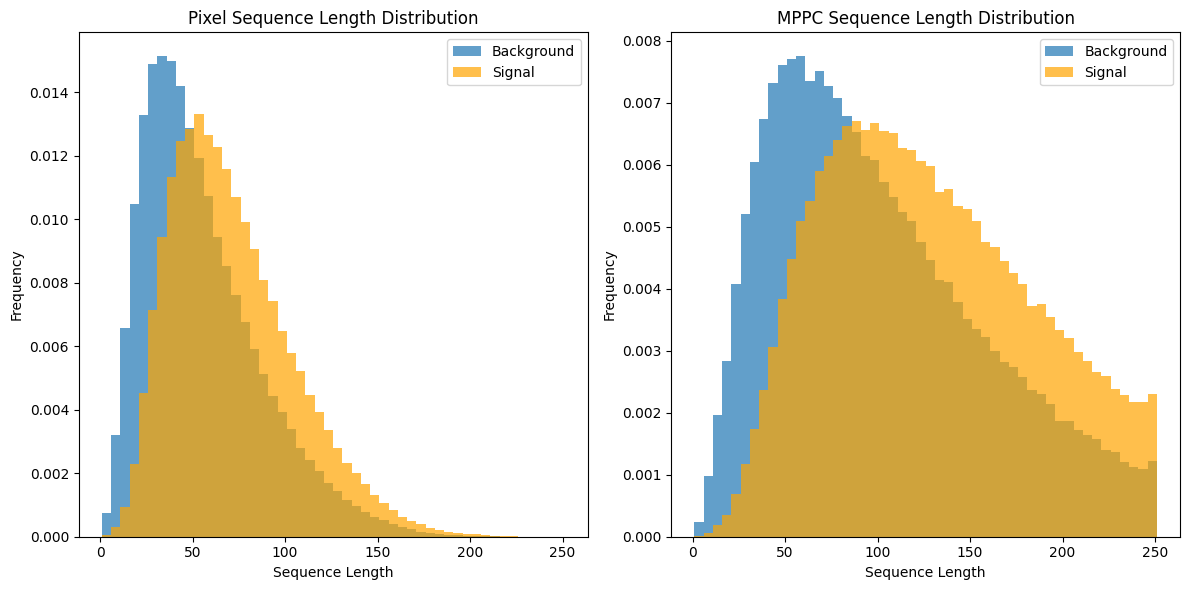

: 

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
bins = np.linspace(1, 251, 51)
ax[0].hist(pixel_seq_length[y == 0], alpha=0.7, bins = bins, label='Background', density=True)
ax[0].hist(pixel_seq_length[y == 1], alpha=0.7, bins = bins, label='Signal', color='orange', density=True)
ax[0].set_title('Pixel Sequence Length Distribution')
ax[0].set_xlabel('Sequence Length')
ax[0].set_ylabel('Frequency')
ax[0].legend()
ax[1].hist(mppc_seq_length[y == 0], alpha=0.7, bins = bins, label='Background', density=True)
ax[1].hist(mppc_seq_length[y == 1], alpha=0.7, bins = bins, label='Signal', color='orange', density=True)
ax[1].legend()
ax[1].set_title('MPPC Sequence Length Distribution')
ax[1].set_xlabel('Sequence Length')
ax[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [2]:
from src.model.components import SelfAttentionStack, PoolingAttentionBlock, MLP

In [3]:
input = keras.layers.Input(shape=(8,4))
attention = SelfAttentionStack(3, 4)(input)
pooling = PoolingAttentionBlock(4, 1)(attention)
output = MLP(1, activation="sigmoid")(pooling)
output = keras.layers.Flatten()(output)


model = keras.models.Model(inputs=input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [4]:
model.get_weights()

[array([1., 1., 1., 1.], dtype=float32),
 array([0., 0., 0., 0.], dtype=float32),
 array([1., 1., 1., 1.], dtype=float32),
 array([0., 0., 0., 0.], dtype=float32),
 array([[[ 0.15856004, -0.21805026,  0.27794874, -0.0168004 ],
         [ 0.29718667,  0.27414948,  0.10467565, -0.2231717 ],
         [ 0.21091706,  0.09704417,  0.29796487, -0.18223482]],
 
        [[ 0.04014993,  0.37565345,  0.05032307, -0.44508335],
         [-0.01884383, -0.37677905,  0.08730572, -0.07498896],
         [-0.4460122 ,  0.0478937 , -0.09729788, -0.13989377]],
 
        [[-0.14037088,  0.07612783,  0.27247304,  0.3812768 ],
         [ 0.14582771, -0.10608998,  0.1164068 , -0.02178633],
         [ 0.36073685, -0.24656518, -0.26004168,  0.4581995 ]],
 
        [[ 0.41324848, -0.1968723 , -0.33386815, -0.2282565 ],
         [ 0.08938205, -0.11921486,  0.44150215, -0.38888237],
         [ 0.1663701 ,  0.10888821, -0.3433836 ,  0.0682925 ]]],
       dtype=float32),
 array([[0., 0., 0., 0.],
        [0., 0., 0.,

In [5]:
dummy_data = tf.random.normal((500, 8, 4))
labels = tf.random.uniform((500, 1), maxval=2, dtype=tf.int32)
model.predict(dummy_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step


array([[0.5832078 ],
       [0.5945133 ],
       [0.59529257],
       [0.6489097 ],
       [0.60562956],
       [0.62259775],
       [0.59440726],
       [0.588374  ],
       [0.67383134],
       [0.6165422 ],
       [0.6067869 ],
       [0.5775093 ],
       [0.57047945],
       [0.6132875 ],
       [0.5955046 ],
       [0.60579926],
       [0.57449144],
       [0.56545407],
       [0.624006  ],
       [0.6310835 ],
       [0.59348106],
       [0.58545464],
       [0.6408163 ],
       [0.60825473],
       [0.5811328 ],
       [0.65565574],
       [0.674694  ],
       [0.61032987],
       [0.6443001 ],
       [0.58363044],
       [0.57369286],
       [0.590035  ],
       [0.6348652 ],
       [0.59792846],
       [0.5962781 ],
       [0.65426606],
       [0.6631521 ],
       [0.62415445],
       [0.5764069 ],
       [0.671328  ],
       [0.63048154],
       [0.6219503 ],
       [0.6080246 ],
       [0.59136224],
       [0.6005408 ],
       [0.568971  ],
       [0.5771723 ],
       [0.618

In [6]:
model.fit(dummy_data, labels, epochs = 3)
model.predict(dummy_data)

Epoch 1/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.5280 - loss: 0.7007
Epoch 2/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5380 - loss: 0.6922
Epoch 3/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5320 - loss: 0.6905
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([[0.5294905 ],
       [0.5189922 ],
       [0.52790767],
       [0.5116367 ],
       [0.5179182 ],
       [0.52564704],
       [0.5143084 ],
       [0.5375464 ],
       [0.5222277 ],
       [0.51991165],
       [0.52169085],
       [0.5199467 ],
       [0.5163963 ],
       [0.53241354],
       [0.5248819 ],
       [0.5162197 ],
       [0.51677364],
       [0.5197186 ],
       [0.5231691 ],
       [0.5237979 ],
       [0.52080965],
       [0.5281791 ],
       [0.5434008 ],
       [0.49687612],
       [0.51961976],
       [0.5204479 ],
       [0.53511935],
       [0.5205309 ],
       [0.57189643],
       [0.5236906 ],
       [0.5021528 ],
       [0.5215776 ],
       [0.52906644],
       [0.53587216],
       [0.49687612],
       [0.5194657 ],
       [0.5144712 ],
       [0.5484631 ],
       [0.51356345],
       [0.5699956 ],
       [0.49687612],
       [0.50341773],
       [0.53556824],
       [0.52701265],
       [0.5221711 ],
       [0.5186933 ],
       [0.51744753],
       [0.517

In [7]:
model.get_weights()

[array([1.0012711, 0.9863478, 1.0057558, 0.98835  ], dtype=float32),
 array([ 0.00651763,  0.01067065,  0.01095894, -0.01063094], dtype=float32),
 array([0.9998335, 1.0106428, 1.0042137, 0.9958779], dtype=float32),
 array([ 0.00344036, -0.01092684, -0.00549837,  0.00742725], dtype=float32),
 array([[[ 0.16171269, -0.22690952,  0.2794826 , -0.00750519],
         [ 0.2887142 ,  0.279554  ,  0.09764066, -0.22820954],
         [ 0.2037061 ,  0.10289362,  0.28993717, -0.18237053]],
 
        [[ 0.03922977,  0.38049164,  0.0502115 , -0.44914654],
         [-0.01353379, -0.37374136,  0.08834034, -0.0670072 ],
         [-0.43966824,  0.03906201, -0.09549828, -0.12950692]],
 
        [[-0.13930471,  0.07845459,  0.27322727,  0.38252422],
         [ 0.14778136, -0.10639413,  0.11872378, -0.0254238 ],
         [ 0.36145982, -0.24435827, -0.2562553 ,  0.45393798]],
 
        [[ 0.41007498, -0.19266376, -0.3357991 , -0.23685074],
         [ 0.09284755, -0.12837529,  0.44795895, -0.38857737],
      

In [8]:
model.save('test_model.keras')

In [9]:
test = keras.models.load_model('test_model.keras', custom_objects={'SelfAttentionStack': SelfAttentionStack, "MLP": MLP, "PoolingAttentionBlock": PoolingAttentionBlock})

In [10]:
non_match_count = 0
for test_weight in model.get_weights():
    match_found = False
    for weight in test.get_weights():
        if weight.shape == test_weight.shape:
            if tf.reduce_all(tf.equal(weight, test_weight)):
                match_found = True
                break
    if not match_found:
        print("Mismatch found in weights!")
        non_match_count += 1

print(f"Total non-matching weights: {non_match_count} of {len(model.get_weights())}")


Total non-matching weights: 0 of 77


In [11]:
test.predict(dummy_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step


array([[0.5294905 ],
       [0.5189922 ],
       [0.52790767],
       [0.5116367 ],
       [0.5179182 ],
       [0.52564704],
       [0.5143084 ],
       [0.5375464 ],
       [0.5222277 ],
       [0.51991165],
       [0.52169085],
       [0.5199467 ],
       [0.5163963 ],
       [0.53241354],
       [0.5248819 ],
       [0.5162197 ],
       [0.51677364],
       [0.5197186 ],
       [0.5231691 ],
       [0.5237979 ],
       [0.52080965],
       [0.5281791 ],
       [0.5434008 ],
       [0.49687612],
       [0.51961976],
       [0.5204479 ],
       [0.53511935],
       [0.5205309 ],
       [0.57189643],
       [0.5236906 ],
       [0.5021528 ],
       [0.5215776 ],
       [0.52906644],
       [0.53587216],
       [0.49687612],
       [0.5194657 ],
       [0.5144712 ],
       [0.5484631 ],
       [0.51356345],
       [0.5699956 ],
       [0.49687612],
       [0.50341773],
       [0.53556824],
       [0.52701265],
       [0.5221711 ],
       [0.5186933 ],
       [0.51744753],
       [0.517